In [7]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow Version:", tf.__version__)
print("NumPy Version:", np.__version__)

TensorFlow Version: 2.20.0
NumPy Version: 2.5.2


In [8]:
# Load Fashion-MNIST dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [9]:
print("DATASET DIMENSIONS")
print("=" * 40)

print("Training images :", X_train.shape)
print("Training labels :", y_train.shape)
print("Testing images  :", X_test.shape)
print("Testing labels  :", y_test.shape)

DATASET DIMENSIONS
Training images : (60000, 28, 28)
Training labels : (60000,)
Testing images  : (10000, 28, 28)
Testing labels  : (10000,)


In [10]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print("Fashion-MNIST Classes")
print("=" * 40)

for i, name in enumerate(class_names):
    print(f"{i}: {name}")

Fashion-MNIST Classes
0: T-shirt/top
1: Trouser
2: Pullover
3: Dress
4: Coat
5: Sandal
6: Shirt
7: Sneaker
8: Bag
9: Ankle boot


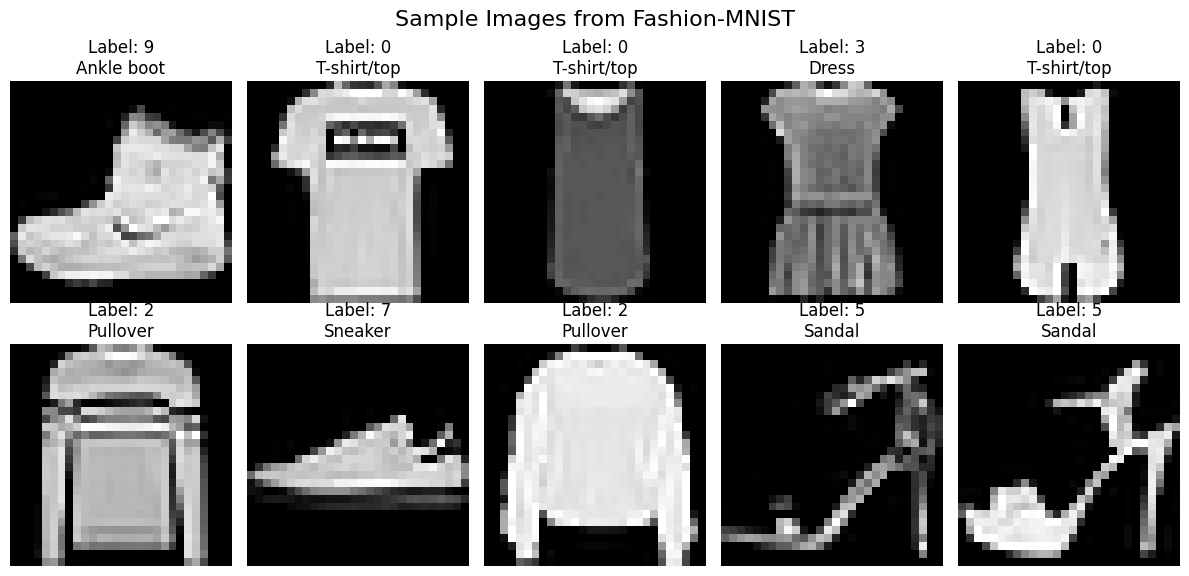

In [11]:
plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(X_train[i], cmap="gray")

    plt.title(
        f"Label: {y_train[i]}\n{class_names[y_train[i]]}"
    )

    plt.axis("off")

plt.suptitle("Sample Images from Fashion-MNIST", fontsize=16)
plt.tight_layout()
plt.show()

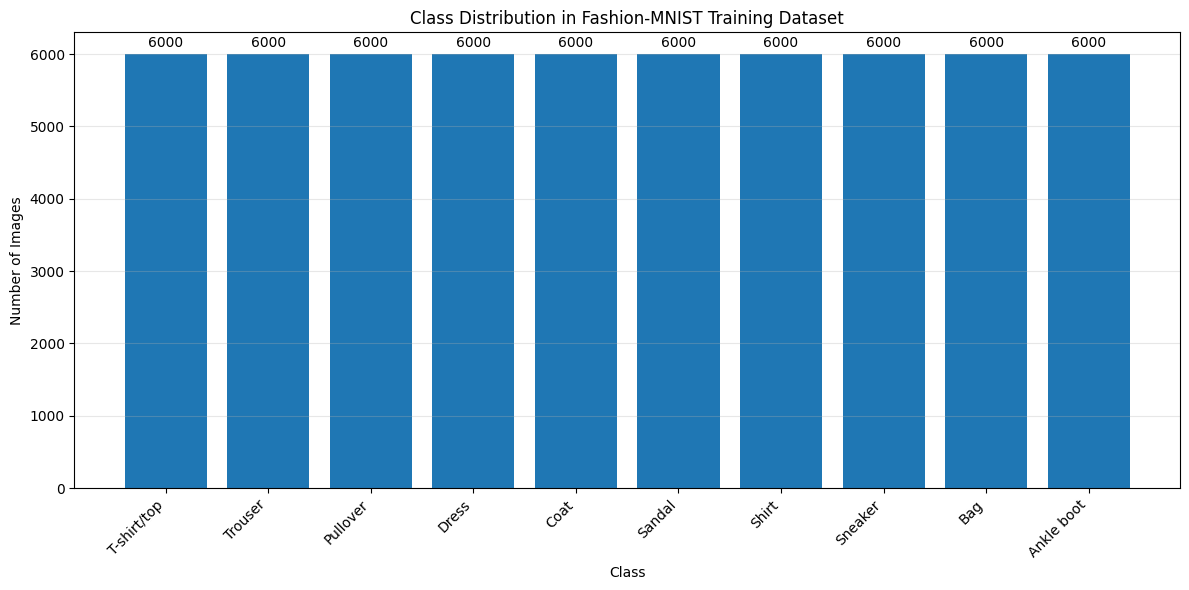

In [12]:
# Count samples belonging to each class
class_counts = np.bincount(y_train)

plt.figure(figsize=(12, 6))

bars = plt.bar(
    range(10),
    class_counts
)

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution in Fashion-MNIST Training Dataset")

plt.xticks(
    range(10),
    class_names,
    rotation=45,
    ha="right"
)

# Display count above each bar
for i, count in enumerate(class_counts):
    plt.text(
        i,
        count + 100,
        str(count),
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
print("PIXEL VALUE INFORMATION")
print("=" * 40)

print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())
print("Data type:", X_train.dtype)

PIXEL VALUE INFORMATION
Minimum pixel value: 0
Maximum pixel value: 255
Data type: uint8


In [15]:
print("SHAPES BEFORE PREPROCESSING")
print("=" * 45)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

print("\nImage dimensions:", X_train.shape[1], "×", X_train.shape[2])
print("Pixels per image:", X_train.shape[1] * X_train.shape[2])

SHAPES BEFORE PREPROCESSING
X_train shape: (60000, 28, 28)
X_test shape : (10000, 28, 28)
y_train shape: (60000,)
y_test shape : (10000,)

Image dimensions: 28 × 28
Pixels per image: 784


In [16]:
# Flatten 28 × 28 images into 784-dimensional vectors

X_train_flat = X_train.reshape(X_train.shape[0], 784)
X_test_flat = X_test.reshape(X_test.shape[0], 784)

print("AFTER FLATTENING")
print("=" * 45)

print("X_train_flat shape:", X_train_flat.shape)
print("X_test_flat shape :", X_test_flat.shape)

AFTER FLATTENING
X_train_flat shape: (60000, 784)
X_test_flat shape : (10000, 784)


In [17]:
# Normalize pixel values from [0, 255] to [0, 1]

X_train_flat = X_train_flat.astype("float32") / 255.0
X_test_flat = X_test_flat.astype("float32") / 255.0

print("PIXEL VALUES AFTER NORMALIZATION")
print("=" * 45)

print("Minimum value:", X_train_flat.min())
print("Maximum value:", X_train_flat.max())
print("Data type:", X_train_flat.dtype)

PIXEL VALUES AFTER NORMALIZATION
Minimum value: 0.0
Maximum value: 1.0
Data type: float32


In [18]:
# Convert class labels to one-hot encoded vectors

y_train_onehot = keras.utils.to_categorical(y_train, 10)
y_test_onehot = keras.utils.to_categorical(y_test, 10)

print("ONE-HOT ENCODING")
print("=" * 45)

print("Original label:", y_train[0])
print("One-hot label :", y_train_onehot[0])

print("\ny_train_onehot shape:", y_train_onehot.shape)
print("y_test_onehot shape :", y_test_onehot.shape)

ONE-HOT ENCODING
Original label: 9
One-hot label : [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]

y_train_onehot shape: (60000, 10)
y_test_onehot shape : (10000, 10)


In [19]:
print("FINAL PREPROCESSING SUMMARY")
print("=" * 55)

print("                    BEFORE              AFTER")
print("-" * 55)

print(f"Training images     {str(X_train.shape):<20} {str(X_train_flat.shape)}")
print(f"Testing images      {str(X_test.shape):<20} {str(X_test_flat.shape)}")

print(f"Training labels     {str(y_train.shape):<20} {str(y_train_onehot.shape)}")
print(f"Testing labels      {str(y_test.shape):<20} {str(y_test_onehot.shape)}")

print("-" * 55)

print("Original pixel range : 0 - 255")
print("Normalized range     : 0.0 - 1.0")
print("Features per image   : 784")
print("Number of classes    : 10")

FINAL PREPROCESSING SUMMARY
                    BEFORE              AFTER
-------------------------------------------------------
Training images     (60000, 28, 28)      (60000, 784)
Testing images      (10000, 28, 28)      (10000, 784)
Training labels     (60000,)             (60000, 10)
Testing labels      (10000,)             (10000, 10)
-------------------------------------------------------
Original pixel range : 0 - 255
Normalized range     : 0.0 - 1.0
Features per image   : 784
Number of classes    : 10


In [20]:
# Create the MLP model

model = keras.Sequential([
    keras.Input(shape=(784,)),

    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

print("MLP model created successfully!")

MLP model created successfully!


In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
print("MODEL ARCHITECTURE")
print("=" * 55)

print("Input Layer       : 784 neurons")
print("Hidden Layer 1    : 128 neurons, ReLU")
print("Hidden Layer 2    : 64 neurons, ReLU")
print("Output Layer      : 10 neurons, Softmax")

print("\nTOTAL PARAMETERS")
print("=" * 55)

print(f"Total parameters     : {model.count_params():,}")
print(f"Trainable parameters : {sum(np.prod(v.shape) for v in model.trainable_weights):,}")

MODEL ARCHITECTURE
Input Layer       : 784 neurons
Hidden Layer 1    : 128 neurons, ReLU
Hidden Layer 2    : 64 neurons, ReLU
Output Layer      : 10 neurons, Softmax

TOTAL PARAMETERS
Total parameters     : 109,386
Trainable parameters : 109,386


In [23]:
# Take the first 5 test images
sample_data = X_test_flat[:5]

# Generate predictions
sample_predictions = model.predict(sample_data, verbose=0)

print("MODEL OUTPUT SHAPE")
print("=" * 40)

print("Input shape :", sample_data.shape)
print("Output shape:", sample_predictions.shape)

print("\nFirst sample output probabilities:")
print(sample_predictions[0])

print("\nSum of probabilities:")
print(np.sum(sample_predictions[0]))

MODEL OUTPUT SHAPE
Input shape : (5, 784)
Output shape: (5, 10)

First sample output probabilities:
[0.0821449  0.05948824 0.09750565 0.08389055 0.06370609 0.10742404
 0.14424829 0.10323037 0.12069976 0.13766214]

Sum of probabilities:
1.0


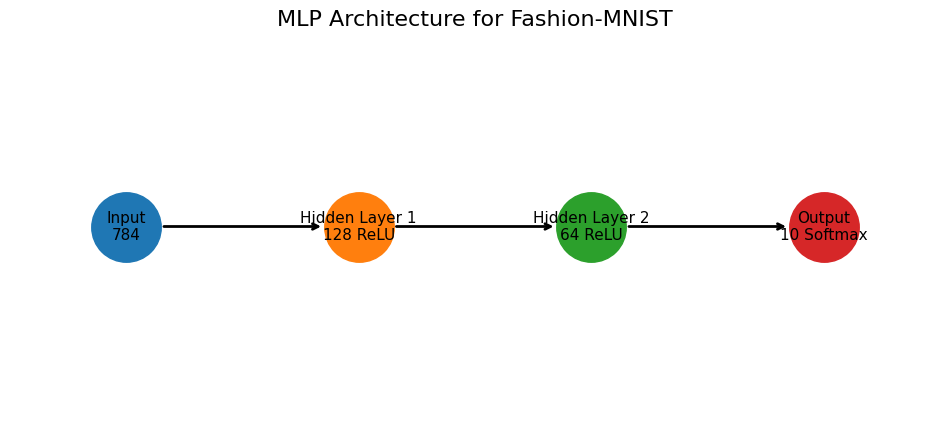

In [24]:
plt.figure(figsize=(12, 5))

layer_names = [
    "Input\n784",
    "Hidden Layer 1\n128 ReLU",
    "Hidden Layer 2\n64 ReLU",
    "Output\n10 Softmax"
]

x_positions = [0, 1, 2, 3]

for x, name in zip(x_positions, layer_names):
    plt.scatter(x, 0, s=2500)
    plt.text(
        x,
        0,
        name,
        ha="center",
        va="center",
        fontsize=11
    )

for i in range(len(x_positions) - 1):
    plt.annotate(
        "",
        xy=(x_positions[i + 1] - 0.15, 0),
        xytext=(x_positions[i] + 0.15, 0),
        arrowprops=dict(arrowstyle="->", lw=2)
    )

plt.xlim(-0.5, 3.5)
plt.ylim(-1, 1)
plt.axis("off")

plt.title(
    "MLP Architecture for Fashion-MNIST",
    fontsize=16
)

plt.show()


In [25]:
# Compile the MLP model

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")
print("\nTraining Configuration")
print("=" * 45)
print("Optimizer : Adam")
print("Loss      : Categorical Cross-Entropy")
print("Metric    : Accuracy")
print("Epochs    : 20")
print("Batch Size: 32")

Model compiled successfully!

Training Configuration
Optimizer : Adam
Loss      : Categorical Cross-Entropy
Metric    : Accuracy
Epochs    : 20
Batch Size: 32


In [26]:
import time

# Start training timer
start_time = time.time()

history = model.fit(
    X_train_flat,
    y_train_onehot,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Calculate training time
training_time = time.time() - start_time

print("\nTraining completed!")
print(f"Total training time: {training_time:.2f} seconds")

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8158 - loss: 0.5164 - val_accuracy: 0.8542 - val_loss: 0.4117
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8623 - loss: 0.3785 - val_accuracy: 0.8657 - val_loss: 0.3704
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8748 - loss: 0.3415 - val_accuracy: 0.8624 - val_loss: 0.3673
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8823 - loss: 0.3162 - val_accuracy: 0.8756 - val_loss: 0.3477
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8891 - loss: 0.2977 - val_accuracy: 0.8605 - val_loss: 0.3893
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8929 - loss: 0.2855 - val_accuracy: 0.8827 - val_loss: 0.3324
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8991 - loss: 0.2712 - val_accuracy: 0.8776 - val_loss: 0.3478
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9032 - loss: 0.2594 - 

In [27]:
print("TRAINING HISTORY")
print("=" * 70)

print(
    f"{'Epoch':<10}"
    f"{'Training Accuracy':<20}"
    f"{'Validation Accuracy':<22}"
    f"{'Training Loss':<18}"
    f"{'Validation Loss':<18}"
)

print("-" * 70)

for i in range(20):
    print(
        f"{i + 1:<10}"
        f"{history.history['accuracy'][i]:<20.4f}"
        f"{history.history['val_accuracy'][i]:<22.4f}"
        f"{history.history['loss'][i]:<18.4f}"
        f"{history.history['val_loss'][i]:<18.4f}"
    )

TRAINING HISTORY
Epoch     Training Accuracy   Validation Accuracy   Training Loss     Validation Loss   
----------------------------------------------------------------------
1         0.8158              0.8542                0.5164            0.4117            
2         0.8623              0.8657                0.3785            0.3704            
3         0.8748              0.8624                0.3415            0.3673            
4         0.8823              0.8756                0.3162            0.3477            
5         0.8891              0.8605                0.2977            0.3893            
6         0.8929              0.8827                0.2855            0.3324            
7         0.8991              0.8776                0.2712            0.3478            
8         0.9032              0.8889                0.2594            0.3153            
9         0.9067              0.8784                0.2508            0.3500            
10        0.9105      

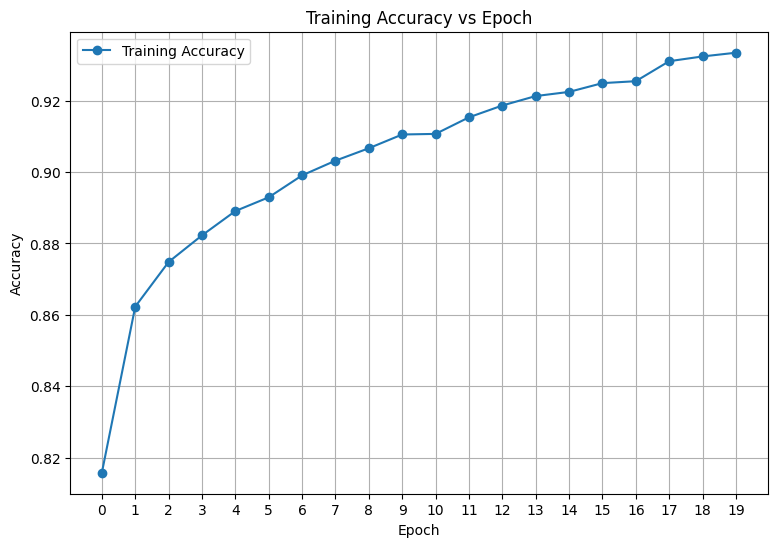

In [28]:
plt.figure(figsize=(9, 6))

plt.plot(
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training Accuracy vs Epoch")

plt.xticks(range(20))
plt.grid(True)
plt.legend()

plt.show()

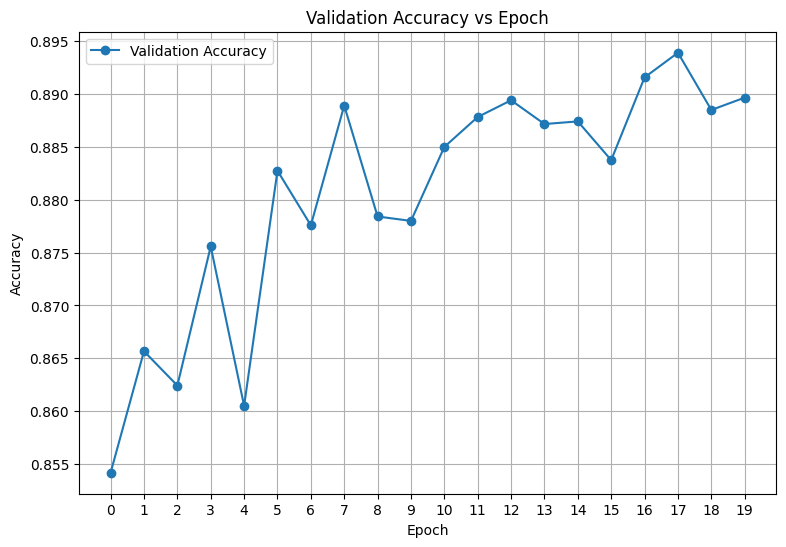

In [29]:
plt.figure(figsize=(9, 6))

plt.plot(
    history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Validation Accuracy vs Epoch")

plt.xticks(range(20))
plt.grid(True)
plt.legend()

plt.show()

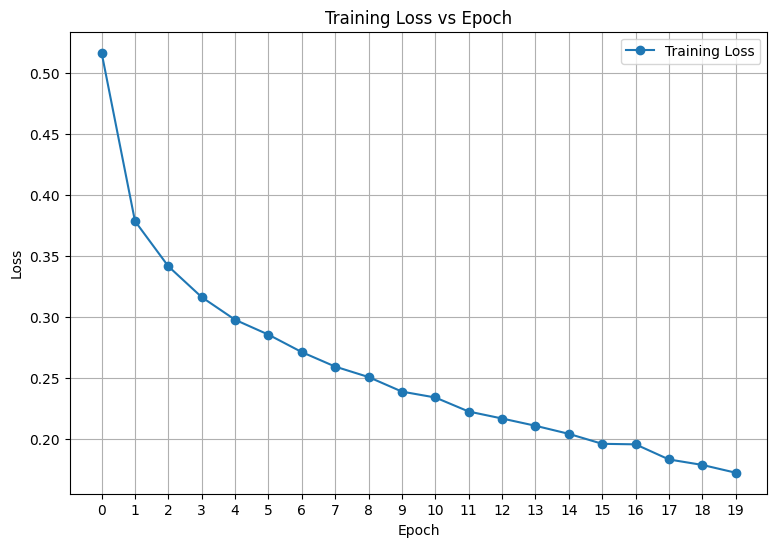

In [30]:
plt.figure(figsize=(9, 6))

plt.plot(
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training Loss vs Epoch")

plt.xticks(range(20))
plt.grid(True)
plt.legend()

plt.show()

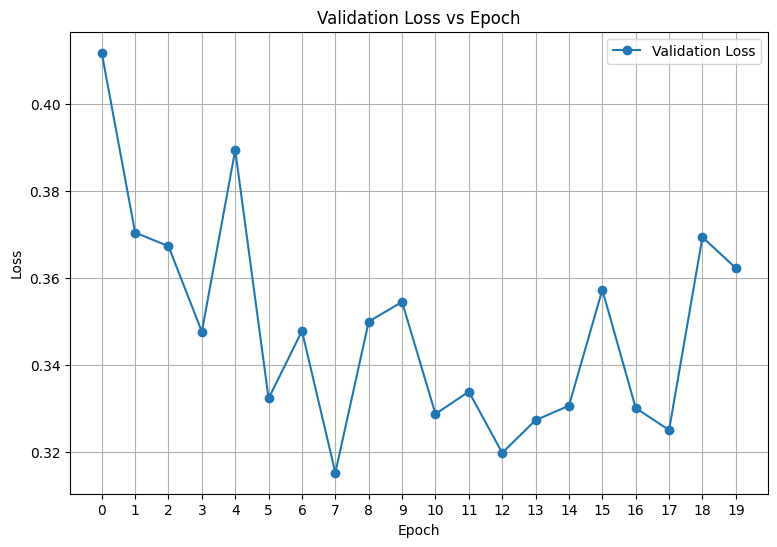

In [31]:
plt.figure(figsize=(9, 6))

plt.plot(
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Validation Loss vs Epoch")

plt.xticks(range(20))
plt.grid(True)
plt.legend()

plt.show()

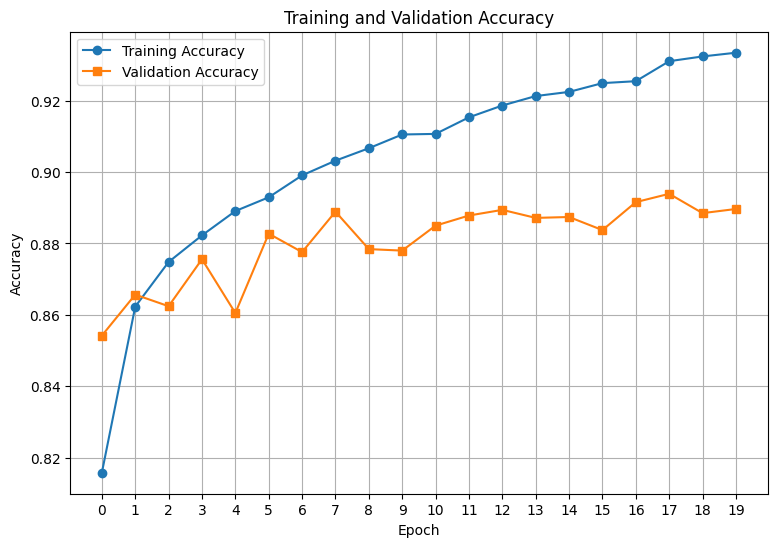

In [32]:
plt.figure(figsize=(9, 6))

plt.plot(
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    marker="s",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training and Validation Accuracy")

plt.xticks(range(20))
plt.grid(True)
plt.legend()

plt.show()

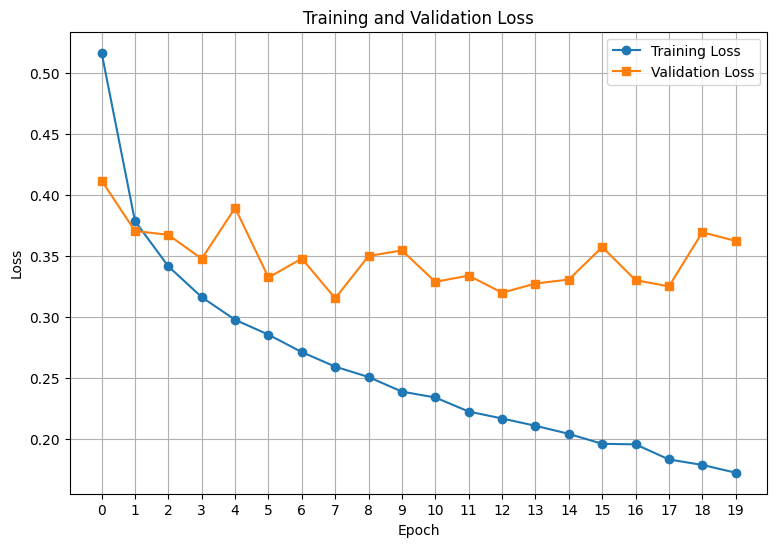

In [33]:
plt.figure(figsize=(9, 6))

plt.plot(
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    marker="s",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training and Validation Loss")

plt.xticks(range(20))
plt.grid(True)
plt.legend()

plt.show()

In [34]:
# Find the best validation accuracy
best_val_accuracy = max(history.history["val_accuracy"])
best_val_epoch = history.history["val_accuracy"].index(best_val_accuracy) + 1

# Find the lowest validation loss
best_val_loss = min(history.history["val_loss"])
best_loss_epoch = history.history["val_loss"].index(best_val_loss) + 1

print("BEST VALIDATION PERFORMANCE")
print("=" * 50)

print(
    f"Best Validation Accuracy : "
    f"{best_val_accuracy:.4f} "
    f"(Epoch {best_val_epoch})"
)

print(
    f"Lowest Validation Loss   : "
    f"{best_val_loss:.4f} "
    f"(Epoch {best_loss_epoch})"
)

print(f"\nTotal Training Time      : {training_time:.2f} seconds")

BEST VALIDATION PERFORMANCE
Best Validation Accuracy : 0.8939 (Epoch 18)
Lowest Validation Loss   : 0.3153 (Epoch 8)

Total Training Time      : 112.36 seconds


In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Evaluation libraries imported successfully!")

Evaluation libraries imported successfully!


In [36]:
# Generate probability predictions
y_pred_prob = model.predict(
    X_test_flat,
    verbose=1
)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)

# Original test labels
y_true = y_test

print("\nPrediction completed!")
print("Prediction shape:", y_pred.shape)
print("Actual label shape:", y_true.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Prediction completed!
Prediction shape: (10000,)
Actual label shape: (10000,)


In [37]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

print("TEST SET ACCURACY")
print("=" * 45)
print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")

TEST SET ACCURACY
Accuracy: 0.8818
Accuracy: 88.18%


In [38]:
precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("TEST SET PERFORMANCE METRICS")
print("=" * 50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

TEST SET PERFORMANCE METRICS
Accuracy : 0.8818
Precision: 0.8841
Recall   : 0.8818
F1-Score : 0.8816


In [39]:
print("\nBASELINE MLP PERFORMANCE")
print("=" * 55)

metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1
}

for metric_name, value in metrics.items():
    print(f"{metric_name:<15}: {value:.4f} ({value * 100:.2f}%)")

print(f"{'Training Time':<15}: {training_time:.2f} seconds")


BASELINE MLP PERFORMANCE
Accuracy       : 0.8818 (88.18%)
Precision      : 0.8841 (88.41%)
Recall         : 0.8818 (88.18%)
F1-Score       : 0.8816 (88.16%)
Training Time  : 112.36 seconds


In [40]:
print("CLASSIFICATION REPORT")
print("=" * 75)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

 T-shirt/top     0.8174    0.8460    0.8314      1000
     Trouser     0.9809    0.9770    0.9790      1000
    Pullover     0.7440    0.8430    0.7904      1000
       Dress     0.8835    0.9180    0.9004      1000
        Coat     0.8742    0.7020    0.7787      1000
      Sandal     0.9803    0.9460    0.9628      1000
       Shirt     0.7052    0.7080    0.7066      1000
     Sneaker     0.9245    0.9670    0.9453      1000
         Bag     0.9727    0.9630    0.9678      1000
  Ankle boot     0.9585    0.9480    0.9532      1000

    accuracy                         0.8818     10000
   macro avg     0.8841    0.8818    0.8816     10000
weighted avg     0.8841    0.8818    0.8816     10000



In [41]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print("CONFUSION MATRIX")
print("=" * 50)
print(cm)

CONFUSION MATRIX
[[846   2  16  21   2   0 105   1   7   0]
 [  4 977   0  12   1   0   3   0   3   0]
 [ 18   3 843  14  35   0  85   0   2   0]
 [ 21  10   9 918  13   0  26   0   3   0]
 [  8   2 177  44 702   0  64   0   3   0]
 [  1   0   0   0   0 946   0  32   2  19]
 [126   1  86  26  47   0 708   0   6   0]
 [  0   0   0   0   0  10   0 967   1  22]
 [ 10   1   2   4   3   1  12   4 963   0]
 [  1   0   0   0   0   8   1  42   0 948]]


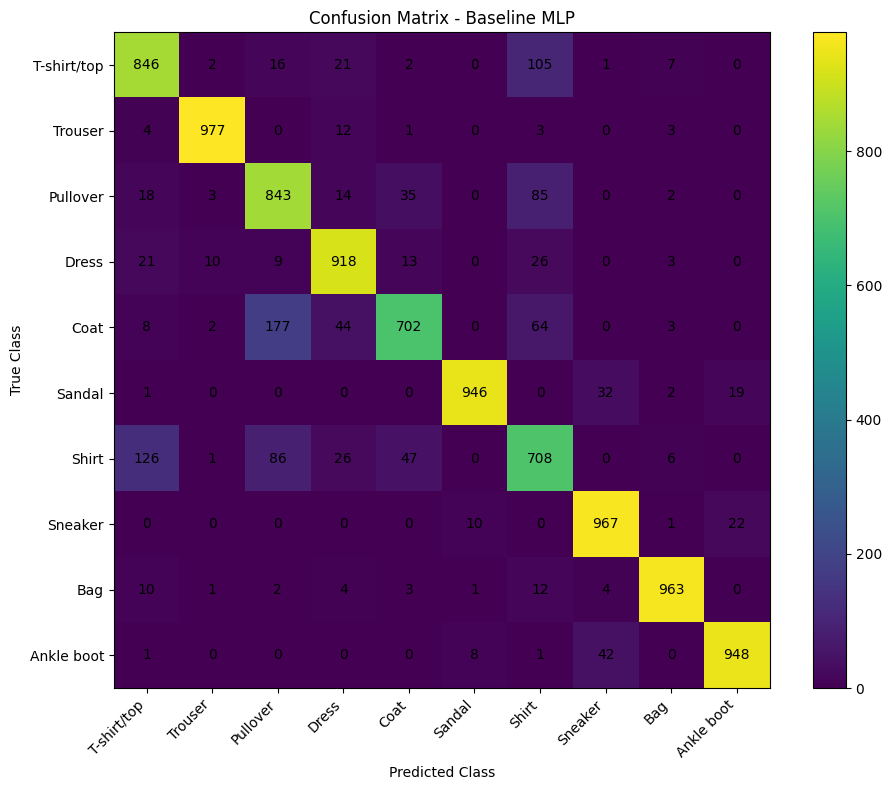

In [42]:
plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.title("Confusion Matrix - Baseline MLP")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(
    range(10),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(10),
    class_names
)

# Display values inside the matrix
for i in range(10):
    for j in range(10):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()
plt.show()

In [43]:
# Remove diagonal values to focus only on incorrect predictions
cm_errors = cm.copy()

np.fill_diagonal(cm_errors, 0)

# Find the largest confusion
max_index = np.unravel_index(
    np.argmax(cm_errors),
    cm_errors.shape
)

actual_class = class_names[max_index[0]]
predicted_class = class_names[max_index[1]]
confusion_count = cm_errors[max_index]

print("CONFUSION ANALYSIS")
print("=" * 55)

print(
    f"Most confused pair:"
    f"\nActual      : {actual_class}"
    f"\nPredicted   : {predicted_class}"
    f"\nCount       : {confusion_count}"
)

CONFUSION ANALYSIS
Most confused pair:
Actual      : Coat
Predicted   : Pullover
Count       : 177


In [44]:
correct_predictions = np.sum(y_true == y_pred)
incorrect_predictions = np.sum(y_true != y_pred)

print("PREDICTION SUMMARY")
print("=" * 50)

print(f"Correct predictions   : {correct_predictions}")
print(f"Incorrect predictions : {incorrect_predictions}")
print(f"Total test samples    : {len(y_true)}")
print(f"Accuracy              : {accuracy * 100:.2f}%")

PREDICTION SUMMARY
Correct predictions   : 8818
Incorrect predictions : 1182
Total test samples    : 10000
Accuracy              : 88.18%


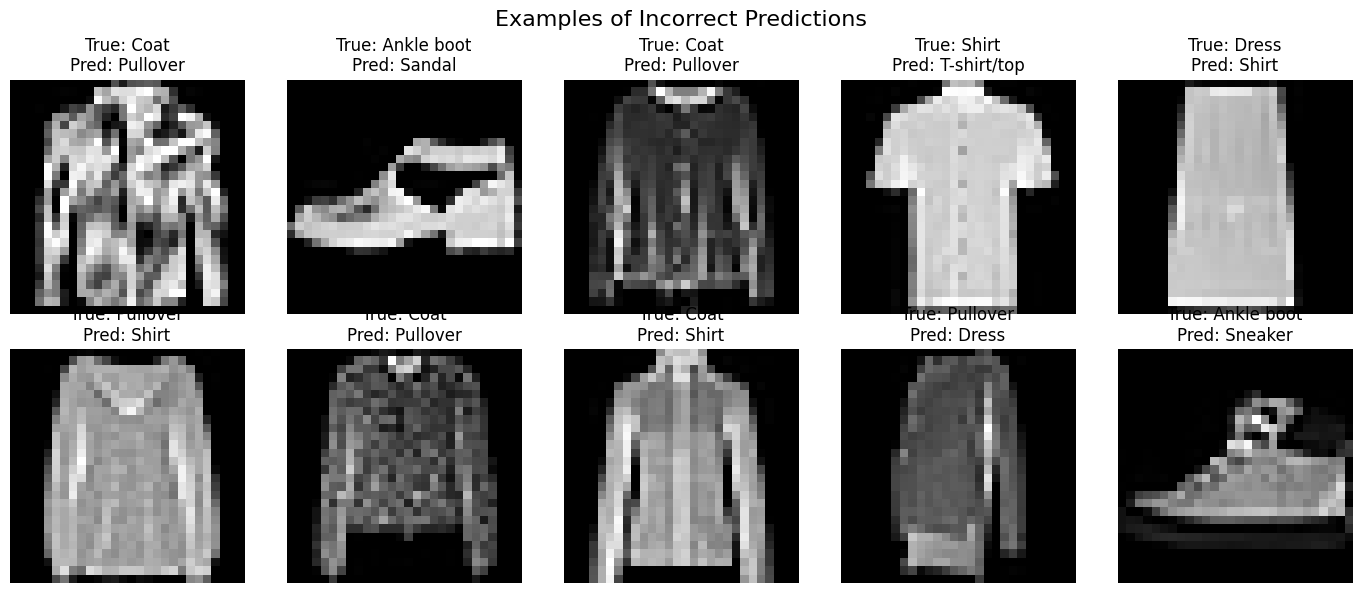

In [45]:
correct_indices = np.where(y_true == y_pred)[0]
incorrect_indices = np.where(y_true != y_pred)[0]

plt.figure(figsize=(14, 6))

for i in range(10):

    index = incorrect_indices[i]

    plt.subplot(2, 5, i + 1)

    plt.imshow(X_test[index], cmap="gray")

    plt.title(
        f"True: {class_names[y_true[index]]}\n"
        f"Pred: {class_names[y_pred[index]]}"
    )

    plt.axis("off")

plt.suptitle(
    "Examples of Incorrect Predictions",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [46]:
print("=" * 65)
print("BASELINE MLP - FINAL EVALUATION")
print("=" * 65)

print(f"Accuracy        : {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Precision       : {precision:.4f} ({precision * 100:.2f}%)")
print(f"Recall          : {recall:.4f} ({recall * 100:.2f}%)")
print(f"F1-Score        : {f1:.4f} ({f1 * 100:.2f}%)")
print(f"Training Time   : {training_time:.2f} seconds")

print("=" * 65)

BASELINE MLP - FINAL EVALUATION
Accuracy        : 0.8818 (88.18%)
Precision       : 0.8841 (88.41%)
Recall          : 0.8818 (88.18%)
F1-Score        : 0.8816 (88.16%)
Training Time   : 112.36 seconds


In [47]:
import tensorflow as tf
import numpy as np

from tensorflow import keras
from tensorflow.keras import layers

from scikeras.wrappers import KerasClassifier

from sklearn.model_selection import RandomizedSearchCV

print("TensorFlow version :", tf.__version__)
print("SciKeras imported successfully!")
print("RandomizedSearchCV imported successfully!")

TensorFlow version : 2.20.0
SciKeras imported successfully!
RandomizedSearchCV imported successfully!


In [48]:
def create_mlp(
    hidden_layers=2,
    hidden_neurons=128,
    learning_rate=0.001,
    optimizer="adam",
    activation="relu",
    dropout_rate=0.0
):

    model = keras.Sequential()

    # Input layer
    model.add(keras.Input(shape=(784,)))

    # Hidden layers
    for _ in range(hidden_layers):

        model.add(
            layers.Dense(
                hidden_neurons,
                activation=activation
            )
        )

        # Optional dropout
        if dropout_rate > 0:
            model.add(
                layers.Dropout(dropout_rate)
            )

    # Output layer
    model.add(
        layers.Dense(
            10,
            activation="softmax"
        )
    )

    # Select optimizer
    if optimizer == "adam":
        opt = keras.optimizers.Adam(
            learning_rate=learning_rate
        )

    elif optimizer == "sgd":
        opt = keras.optimizers.SGD(
            learning_rate=learning_rate
        )

    elif optimizer == "rmsprop":
        opt = keras.optimizers.RMSprop(
            learning_rate=learning_rate
        )

    # Compile model
    model.compile(
        optimizer=opt,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [49]:
test_model = create_mlp(
    hidden_layers=2,
    hidden_neurons=64,
    learning_rate=0.001,
    optimizer="adam",
    activation="relu",
    dropout_rate=0.0
)

test_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,050 (215.04 KB)

 Trainable params: 55,050 (215.04 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
mlp_classifier = KerasClassifier(
    model=create_mlp,
    verbose=0
)

print("SciKeras KerasClassifier created successfully!")

SciKeras KerasClassifier created successfully!


In [51]:
param_grid = {
    "model__hidden_layers": [1, 2, 3],

    "model__hidden_neurons": [32, 64, 128, 256],

    "model__learning_rate": [0.1, 0.01, 0.001],

    "batch_size": [16, 32, 64, 128],

    "epochs": [10, 20, 30],

    "model__optimizer": [
        "sgd",
        "adam",
        "rmsprop"
    ],

    "model__activation": [
        "relu",
        "tanh",
        "sigmoid"
    ],

    "model__dropout_rate": [
        0.0,
        0.2,
        0.5
    ]
}

print("HYPERPARAMETER SEARCH SPACE")
print("=" * 60)

for parameter, values in param_grid.items():
    print(f"{parameter:<30}: {values}")

HYPERPARAMETER SEARCH SPACE
model__hidden_layers          : [1, 2, 3]
model__hidden_neurons         : [32, 64, 128, 256]
model__learning_rate          : [0.1, 0.01, 0.001]
batch_size                    : [16, 32, 64, 128]
epochs                        : [10, 20, 30]
model__optimizer              : ['sgd', 'adam', 'rmsprop']
model__activation             : ['relu', 'tanh', 'sigmoid']
model__dropout_rate           : [0.0, 0.2, 0.5]


In [52]:
random_search = RandomizedSearchCV(
    estimator=mlp_classifier,
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring="accuracy",
    random_state=42,
    verbose=2,
    n_jobs=1
)

print("RandomizedSearchCV configured successfully!")
print("Number of random configurations:", 10)
print("Cross-validation folds:", 5)

RandomizedSearchCV configured successfully!
Number of random configurations: 10
Cross-validation folds: 5


In [53]:
import time

print("STARTING RANDOMIZED HYPERPARAMETER SEARCH")
print("=" * 65)

search_start_time = time.time()

random_search.fit(
    X_train_flat,
    y_train_onehot
)

search_time = time.time() - search_start_time

print("\n" + "=" * 65)
print("HYPERPARAMETER SEARCH COMPLETED")
print("=" * 65)

print(f"Search time: {search_time / 60:.2f} minutes")

STARTING RANDOMIZED HYPERPARAMETER SEARCH
Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer=adam; total time=  48.0s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer=adam; total time=  43.7s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer=adam; total time=  46.2s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer=adam; total time=  46.7s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rat

/usr/local/lib/python3.13/dist-packages/numpy/ma/core.py:2895: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,



HYPERPARAMETER SEARCH COMPLETED
Search time: 74.74 minutes


In [54]:
print("BEST HYPERPARAMETERS")
print("=" * 65)

for parameter, value in random_search.best_params_.items():
    print(f"{parameter:<30}: {value}")

print("\nBest Cross-Validation Accuracy:")
print(f"{random_search.best_score_:.4f}")
print(f"{random_search.best_score_ * 100:.2f}%")

BEST HYPERPARAMETERS
model__optimizer              : adam
model__learning_rate          : 0.001
model__hidden_neurons         : 256
model__hidden_layers          : 2
model__dropout_rate           : 0.0
model__activation             : sigmoid
epochs                        : 30
batch_size                    : 32

Best Cross-Validation Accuracy:
0.8940
89.40%


In [55]:
best_model = random_search.best_estimator_

print("BEST OPTIMIZED MODEL")
print("=" * 60)

best_model.model_.summary()

BEST OPTIMIZED MODEL


Model: "sequential_52"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_146 (Dense)               │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_147 (Dense)               │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_148 (Dense)               │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 807,968 (3.08 MB)

 Trainable params: 269,322 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 538,646 (2.05 MB)

In [56]:
import pandas as pd

results_df = pd.DataFrame(
    random_search.cv_results_
)

selected_columns = [
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "param_model__hidden_layers",
    "param_model__hidden_neurons",
    "param_model__learning_rate",
    "param_batch_size",
    "param_epochs",
    "param_model__optimizer",
    "param_model__activation",
    "param_model__dropout_rate"
]

results_table = results_df[selected_columns].sort_values(
    "rank_test_score"
)

results_table

,rank_test_score,mean_test_score,std_test_score,param_model__hidden_layers,param_model__hidden_neurons,param_model__learning_rate,param_batch_size,param_epochs,param_model__optimizer,param_model__activation,param_model__dropout_rate
9,1,0.893967,0.003900,2,256,0.001,32,30,adam,sigmoid,0.0
0,2,0.888883,0.003011,1,256,0.001,64,20,adam,tanh,0.2
2,3,0.886467,0.003261,3,128,0.001,32,30,rmsprop,tanh,0.2
8,4,0.882750,0.002629,3,256,0.001,32,20,adam,tanh,0.2
3,5,0.878583,0.001978,1,32,0.001,32,30,adam,tanh,0.0
7,6,0.877650,0.004550,1,256,0.001,16,10,adam,tanh,0.2
4,7,0.867183,0.002896,2,64,0.001,128,30,adam,tanh,0.5
1,8,0.835467,0.005980,3,256,0.010,16,10,rmsprop,sigmoid,0.2
5,9,0.682517,0.031116,1,64,0.100,32,30,adam,sigmoid,0.5
6,10,0.643967,0.010164,1,32,0.100,64,10,adam,tanh,0.2


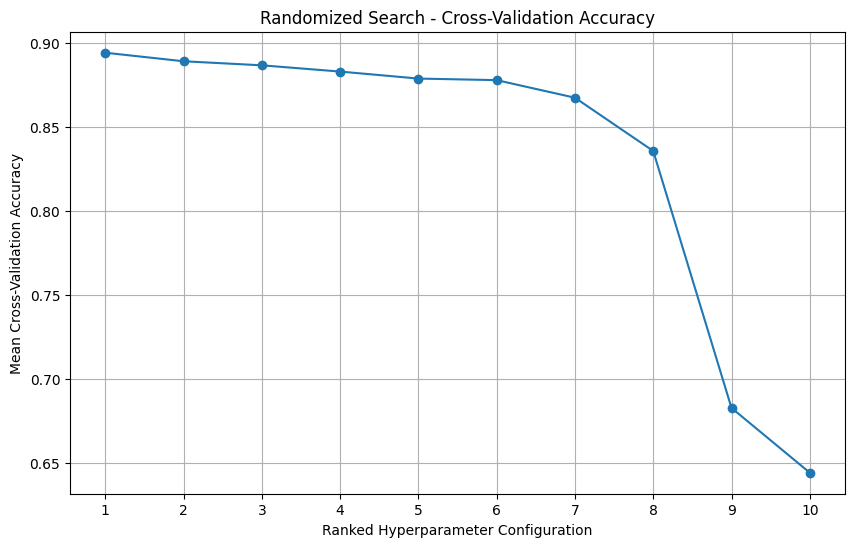

In [57]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(results_table) + 1),
    results_table["mean_test_score"].values,
    marker="o"
)

plt.xlabel("Ranked Hyperparameter Configuration")
plt.ylabel("Mean Cross-Validation Accuracy")

plt.title(
    "Randomized Search - Cross-Validation Accuracy"
)

plt.xticks(
    range(1, len(results_table) + 1)
)

plt.grid(True)

plt.show()

In [58]:
best_params = random_search.best_params_

best_hyperparameters = pd.DataFrame({
    "Hyperparameter": [
        "Hidden Layers",
        "Hidden Neurons",
        "Learning Rate",
        "Batch Size",
        "Optimizer",
        "Activation Function",
        "Epochs",
        "Dropout"
    ],

    "Best Value": [
        best_params["model__hidden_layers"],
        best_params["model__hidden_neurons"],
        best_params["model__learning_rate"],
        best_params["batch_size"],
        best_params["model__optimizer"],
        best_params["model__activation"],
        best_params["epochs"],
        best_params["model__dropout_rate"]
    ]
})

best_hyperparameters

,Hyperparameter,Best Value
0,Hidden Layers,2
1,Hidden Neurons,256
2,Learning Rate,0.001
3,Batch Size,32
4,Optimizer,adam
5,Activation Function,sigmoid
6,Epochs,30
7,Dropout,0.0


In [59]:
print("=" * 65)
print("HYPERPARAMETER OPTIMIZATION SUMMARY")
print("=" * 65)

print(
    f"Optimization Method       : RandomizedSearchCV"
)

print(
    f"Number of Configurations  : {random_search.n_iter}"
)

print(
    f"Cross-Validation Folds    : {random_search.cv}"
)

print(
    f"Best CV Accuracy          : "
    f"{random_search.best_score_:.4f} "
    f"({random_search.best_score_ * 100:.2f}%)"
)

print(
    f"Search Time               : "
    f"{search_time / 60:.2f} minutes"
)

print("=" * 65)

HYPERPARAMETER OPTIMIZATION SUMMARY
Optimization Method       : RandomizedSearchCV
Number of Configurations  : 10
Cross-Validation Folds    : 5
Best CV Accuracy          : 0.8940 (89.40%)
Search Time               : 74.74 minutes


In [60]:
best_params = random_search.best_params_

optimized_model = create_mlp(
    hidden_layers=best_params["model__hidden_layers"],
    hidden_neurons=best_params["model__hidden_neurons"],
    learning_rate=best_params["model__learning_rate"],
    optimizer=best_params["model__optimizer"],
    activation=best_params["model__activation"],
    dropout_rate=best_params["model__dropout_rate"]
)

print("OPTIMIZED MODEL CREATED")
print("=" * 60)

optimized_model.summary()

OPTIMIZED MODEL CREATED


Model: "sequential_53"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_149 (Dense)               │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_150 (Dense)               │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_151 (Dense)               │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,322 (1.03 MB)

 Trainable params: 269,322 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

In [61]:
import time

optimized_start_time = time.time()

optimized_history = optimized_model.fit(
    X_train_flat,
    y_train_onehot,
    epochs=best_params["epochs"],
    batch_size=best_params["batch_size"],
    validation_split=0.2,
    verbose=1
)

optimized_training_time = time.time() - optimized_start_time

print("\n" + "=" * 70)
print("OPTIMIZED MODEL TRAINING COMPLETED")
print("=" * 70)

print(
    f"Training time: "
    f"{optimized_training_time / 60:.2f} minutes"
)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7965 - loss: 0.5687 - val_accuracy: 0.8447 - val_loss: 0.4225
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8567 - loss: 0.3897 - val_accuracy: 0.8668 - val_loss: 0.3682
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8721 - loss: 0.3503 - val_accuracy: 0.8659 - val_loss: 0.3693
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8815 - loss: 0.3237 - val_accuracy: 0.8772 - val_loss: 0.3385
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8863 - loss: 0.3054 - val_accuracy: 0.8830 - val_loss: 0.3183
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8930 - loss: 0.2871 - val_accuracy: 0.8783 - val_loss: 0.3308
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8992 - loss: 0.2701 - val_accuracy: 0.8914 - val_loss: 0.2996
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9028 - loss: 0.2576 - 

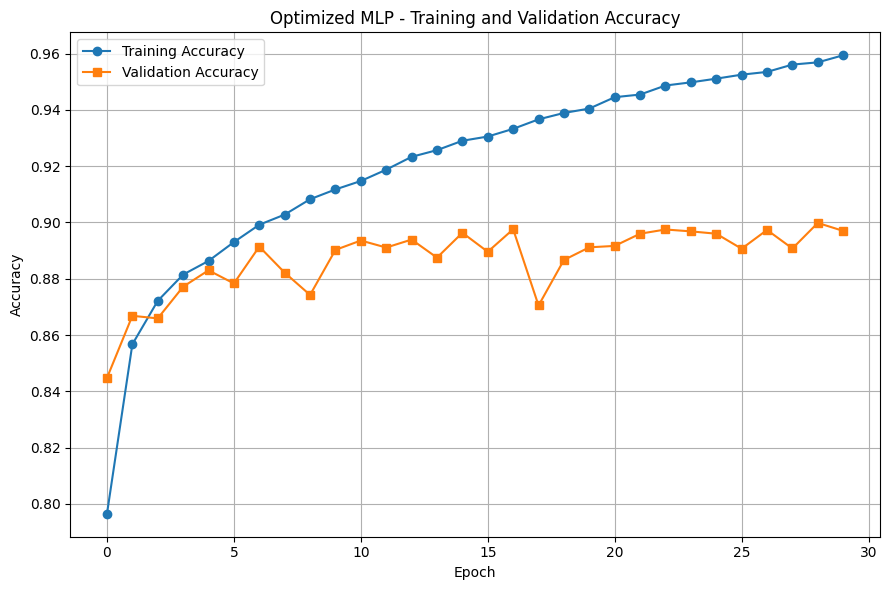

In [62]:
plt.figure(figsize=(9, 6))

plt.plot(
    optimized_history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    optimized_history.history["val_accuracy"],
    marker="s",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Optimized MLP - Training and Validation Accuracy")

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

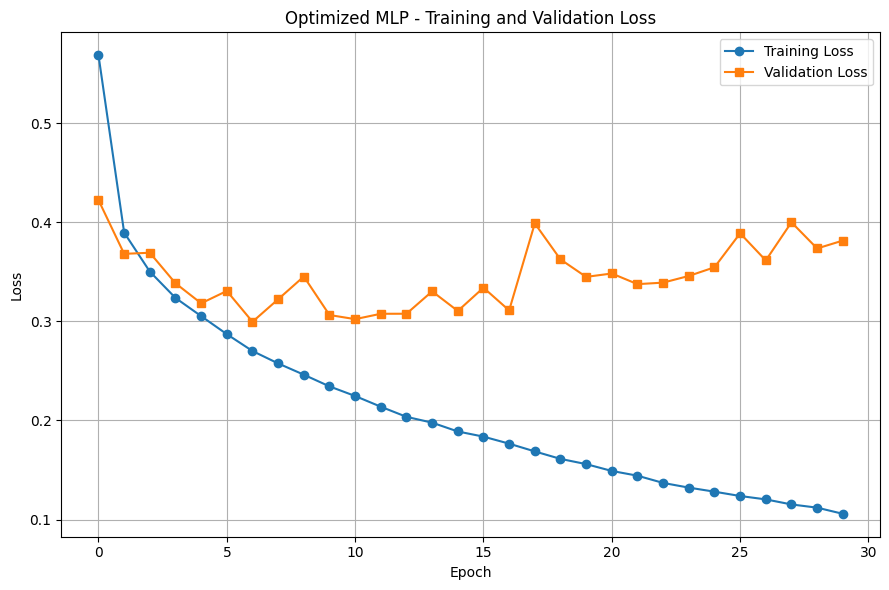

In [63]:
plt.figure(figsize=(9, 6))

plt.plot(
    optimized_history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    optimized_history.history["val_loss"],
    marker="s",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Optimized MLP - Training and Validation Loss")

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [64]:
optimized_pred_prob = optimized_model.predict(
    X_test_flat,
    verbose=1
)

optimized_y_pred = np.argmax(
    optimized_pred_prob,
    axis=1
)

optimized_accuracy = accuracy_score(
    y_test,
    optimized_y_pred
)

optimized_precision = precision_score(
    y_test,
    optimized_y_pred,
    average="weighted"
)

optimized_recall = recall_score(
    y_test,
    optimized_y_pred,
    average="weighted"
)

optimized_f1 = f1_score(
    y_test,
    optimized_y_pred,
    average="weighted"
)

print("=" * 65)
print("OPTIMIZED MLP - TEST SET PERFORMANCE")
print("=" * 65)

print(
    f"Accuracy  : {optimized_accuracy:.4f} "
    f"({optimized_accuracy * 100:.2f}%)"
)

print(
    f"Precision : {optimized_precision:.4f} "
    f"({optimized_precision * 100:.2f}%)"
)

print(
    f"Recall    : {optimized_recall:.4f} "
    f"({optimized_recall * 100:.2f}%)"
)

print(
    f"F1-Score  : {optimized_f1:.4f} "
    f"({optimized_f1 * 100:.2f}%)"
)

print(
    f"Training Time: "
    f"{optimized_training_time / 60:.2f} minutes"
)

print("=" * 65)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
OPTIMIZED MLP - TEST SET PERFORMANCE
Accuracy  : 0.8906 (89.06%)
Precision : 0.8929 (89.29%)
Recall    : 0.8906 (89.06%)
F1-Score  : 0.8912 (89.12%)
Training Time: 2.72 minutes


In [65]:
print("OPTIMIZED MLP - CLASSIFICATION REPORT")
print("=" * 75)

print(
    classification_report(
        y_test,
        optimized_y_pred,
        target_names=class_names,
        digits=4
    )
)

OPTIMIZED MLP - CLASSIFICATION REPORT
              precision    recall  f1-score   support

 T-shirt/top     0.8771    0.7990    0.8362      1000
     Trouser     0.9879    0.9780    0.9829      1000
    Pullover     0.8423    0.7800    0.8100      1000
       Dress     0.8934    0.8970    0.8952      1000
        Coat     0.7811    0.8600    0.8187      1000
      Sandal     0.9708    0.9650    0.9679      1000
       Shirt     0.6856    0.7350    0.7095      1000
     Sneaker     0.9450    0.9620    0.9534      1000
         Bag     0.9818    0.9720    0.9769      1000
  Ankle boot     0.9638    0.9580    0.9609      1000

    accuracy                         0.8906     10000
   macro avg     0.8929    0.8906    0.8912     10000
weighted avg     0.8929    0.8906    0.8912     10000



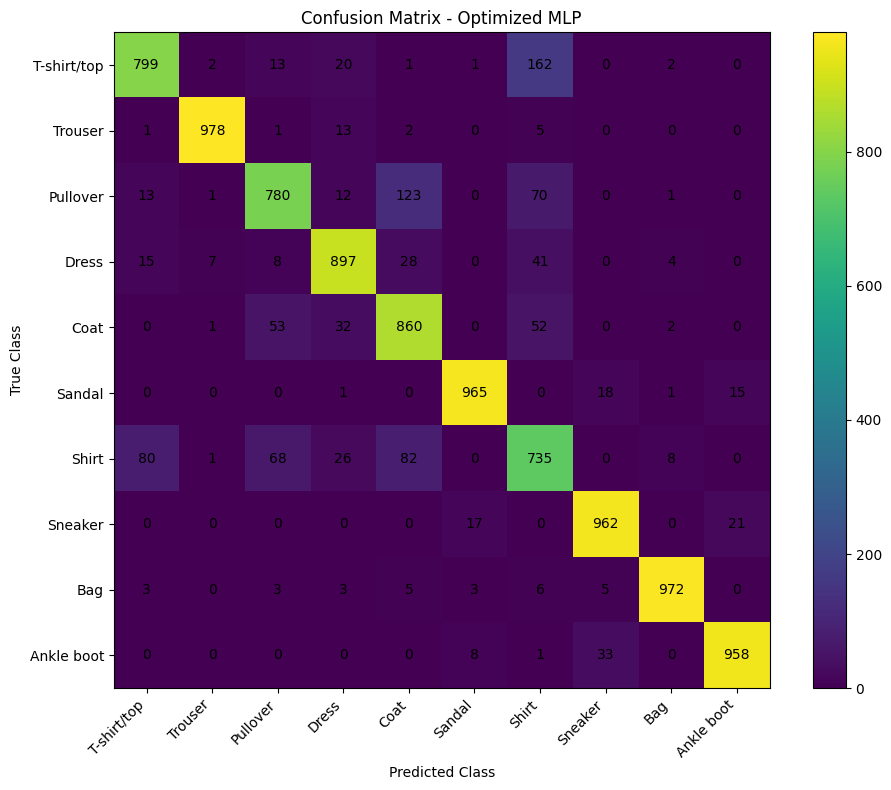

In [66]:
optimized_cm = confusion_matrix(
    y_test,
    optimized_y_pred
)

plt.figure(figsize=(10, 8))

plt.imshow(optimized_cm)

plt.title("Confusion Matrix - Optimized MLP")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(
    range(10),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(10),
    class_names
)

for i in range(10):
    for j in range(10):
        plt.text(
            j,
            i,
            optimized_cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()
plt.show()

In [67]:
comparison_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "Training Time (seconds)"
    ],

    "Baseline MLP": [
        accuracy,
        precision,
        recall,
        f1,
        training_time
    ],

    "Optimized MLP": [
        optimized_accuracy,
        optimized_precision,
        optimized_recall,
        optimized_f1,
        optimized_training_time
    ]
})

print("=" * 75)
print("BASELINE MLP vs OPTIMIZED MLP")
print("=" * 75)

display(comparison_df)

BASELINE MLP vs OPTIMIZED MLP


,Metric,Baseline MLP,Optimized MLP
0,Accuracy,0.881800,0.890600
1,Precision,0.884136,0.892885
2,Recall,0.881800,0.890600
3,F1-Score,0.881576,0.891151
4,Training Time (seconds),112.364874,163.073753


In [68]:
accuracy_improvement = optimized_accuracy - accuracy
precision_improvement = optimized_precision - precision
recall_improvement = optimized_recall - recall
f1_improvement = optimized_f1 - f1

print("=" * 70)
print("PERFORMANCE IMPROVEMENT")
print("=" * 70)

print(
    f"Accuracy improvement  : {accuracy_improvement:+.4f} "
    f"({accuracy_improvement * 100:+.2f} percentage points)"
)

print(
    f"Precision improvement : {precision_improvement:+.4f} "
    f"({precision_improvement * 100:+.2f} percentage points)"
)

print(
    f"Recall improvement    : {recall_improvement:+.4f} "
    f"({recall_improvement * 100:+.2f} percentage points)"
)

print(
    f"F1-score improvement  : {f1_improvement:+.4f} "
    f"({f1_improvement * 100:+.2f} percentage points)"
)

print("=" * 70)

PERFORMANCE IMPROVEMENT
Accuracy improvement  : +0.0088 (+0.88 percentage points)
Precision improvement : +0.0087 (+0.87 percentage points)
Recall improvement    : +0.0088 (+0.88 percentage points)
F1-score improvement  : +0.0096 (+0.96 percentage points)


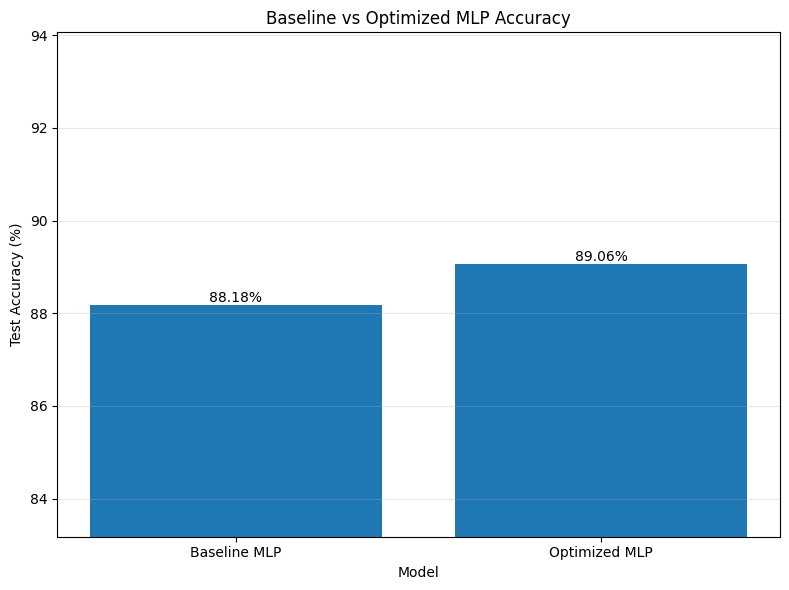

In [69]:
plt.figure(figsize=(8, 6))

models = [
    "Baseline MLP",
    "Optimized MLP"
]

accuracies = [
    accuracy * 100,
    optimized_accuracy * 100
]

bars = plt.bar(
    models,
    accuracies
)

plt.ylabel("Test Accuracy (%)")
plt.xlabel("Model")
plt.title("Baseline vs Optimized MLP Accuracy")

plt.ylim(
    max(0, min(accuracies) - 5),
    min(100, max(accuracies) + 5)
)

for bar, value in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

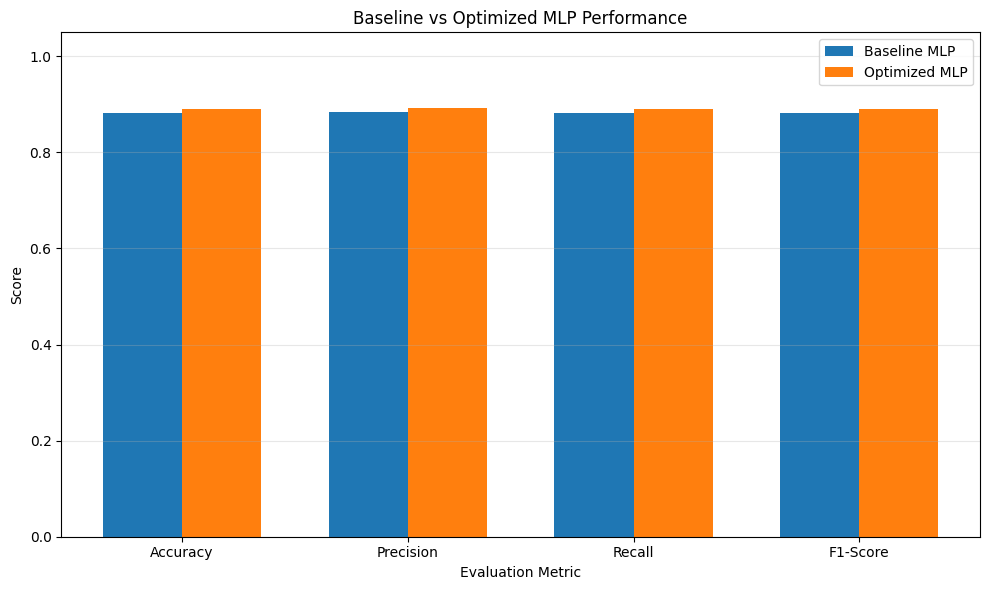

In [70]:
metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

baseline_values = [
    accuracy,
    precision,
    recall,
    f1
]

optimized_values = [
    optimized_accuracy,
    optimized_precision,
    optimized_recall,
    optimized_f1
]

x = np.arange(len(metric_names))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    baseline_values,
    width,
    label="Baseline MLP"
)

plt.bar(
    x + width / 2,
    optimized_values,
    width,
    label="Optimized MLP"
)

plt.xticks(x, metric_names)
plt.ylabel("Score")
plt.xlabel("Evaluation Metric")
plt.title("Baseline vs Optimized MLP Performance")

plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [71]:
best_hyperparameters_table = pd.DataFrame({
    "Hyperparameter": [
        "Hidden Layers",
        "Hidden Neurons",
        "Learning Rate",
        "Batch Size",
        "Optimizer",
        "Activation Function",
        "Epochs",
        "Dropout Rate"
    ],

    "Optimized Value": [
        best_params["model__hidden_layers"],
        best_params["model__hidden_neurons"],
        best_params["model__learning_rate"],
        best_params["batch_size"],
        best_params["model__optimizer"],
        best_params["model__activation"],
        best_params["epochs"],
        best_params["model__dropout_rate"]
    ]
})

print("=" * 65)
print("OPTIMIZED MODEL CONFIGURATION")
print("=" * 65)

display(best_hyperparameters_table)

OPTIMIZED MODEL CONFIGURATION


,Hyperparameter,Optimized Value
0,Hidden Layers,2
1,Hidden Neurons,256
2,Learning Rate,0.001
3,Batch Size,32
4,Optimizer,adam
5,Activation Function,sigmoid
6,Epochs,30
7,Dropout Rate,0.0


In [72]:
print("=" * 75)
print("FINAL EXPERIMENT SUMMARY")
print("=" * 75)

print("\nBASELINE MLP")
print("-" * 75)
print(f"Accuracy        : {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Precision       : {precision:.4f} ({precision * 100:.2f}%)")
print(f"Recall          : {recall:.4f} ({recall * 100:.2f}%)")
print(f"F1-Score        : {f1:.4f} ({f1 * 100:.2f}%)")
print(f"Training Time   : {training_time:.2f} seconds")

print("\nOPTIMIZED MLP")
print("-" * 75)
print(
    f"Accuracy        : "
    f"{optimized_accuracy:.4f} "
    f"({optimized_accuracy * 100:.2f}%)"
)
print(
    f"Precision       : "
    f"{optimized_precision:.4f} "
    f"({optimized_precision * 100:.2f}%)"
)
print(
    f"Recall          : "
    f"{optimized_recall:.4f} "
    f"({optimized_recall * 100:.2f}%)"
)
print(
    f"F1-Score        : "
    f"{optimized_f1:.4f} "
    f"({optimized_f1 * 100:.2f}%)"
)
print(
    f"Training Time   : "
    f"{optimized_training_time:.2f} seconds"
)

print("\nBEST HYPERPARAMETERS")
print("-" * 75)

for parameter, value in best_params.items():
    print(f"{parameter:<30}: {value}")

print("\nBEST CROSS-VALIDATION ACCURACY")
print("-" * 75)
print(
    f"{random_search.best_score_:.4f} "
    f"({random_search.best_score_ * 100:.2f}%)"
)

print("=" * 75)

FINAL EXPERIMENT SUMMARY

BASELINE MLP
---------------------------------------------------------------------------
Accuracy        : 0.8818 (88.18%)
Precision       : 0.8841 (88.41%)
Recall          : 0.8818 (88.18%)
F1-Score        : 0.8816 (88.16%)
Training Time   : 112.36 seconds

OPTIMIZED MLP
---------------------------------------------------------------------------
Accuracy        : 0.8906 (89.06%)
Precision       : 0.8929 (89.29%)
Recall          : 0.8906 (89.06%)
F1-Score        : 0.8912 (89.12%)
Training Time   : 163.07 seconds

BEST HYPERPARAMETERS
---------------------------------------------------------------------------
model__optimizer              : adam
model__learning_rate          : 0.001
model__hidden_neurons         : 256
model__hidden_layers          : 2
model__dropout_rate           : 0.0
model__activation             : sigmoid
epochs                        : 30
batch_size                    : 32

BEST CROSS-VALIDATION ACCURACY
-----------------------------------

In [73]:
results_summary = pd.DataFrame({
    "Model": [
        "Baseline MLP",
        "Optimized MLP"
    ],

    "Accuracy": [
        accuracy,
        optimized_accuracy
    ],

    "Precision": [
        precision,
        optimized_precision
    ],

    "Recall": [
        recall,
        optimized_recall
    ],

    "F1-Score": [
        f1,
        optimized_f1
    ],

    "Training_Time_Seconds": [
        training_time,
        optimized_training_time
    ]
})

results_summary.to_csv(
    "mlp_final_results.csv",
    index=False
)

best_hyperparameters_table.to_csv(
    "mlp_best_hyperparameters.csv",
    index=False
)

print("Results saved successfully!")
print("• mlp_final_results.csv")
print("• mlp_best_hyperparameters.csv")

Results saved successfully!
• mlp_final_results.csv
• mlp_best_hyperparameters.csv


In [74]:
# ============================================================
# SAVE ALL IMPORTANT MLP FIGURES AS HIGH-QUALITY PNG FILES
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

# Create folder
os.makedirs("figures", exist_ok=True)

print("=" * 70)
print("GENERATING MLP REPORT FIGURES")
print("=" * 70)


# ============================================================
# FIGURE 1 — SAMPLE FASHION-MNIST IMAGES
# ============================================================

plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i], cmap="gray")
    plt.title(class_names[y_test[i]])
    plt.axis("off")

plt.suptitle("Sample Fashion-MNIST Images", fontsize=16)
plt.tight_layout()

plt.savefig(
    "figures/01_sample_images.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("✓ Figure 1 saved")


# ============================================================
# FIGURE 2 — CLASS DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

class_counts = np.bincount(y_train)

bars = plt.bar(
    class_names,
    class_counts
)

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Fashion-MNIST Class Distribution")

plt.xticks(
    rotation=45,
    ha="right"
)

for bar, count in zip(bars, class_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(count),
        ha="center",
        va="bottom"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "figures/02_class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("✓ Figure 2 saved")


# ============================================================
# FIGURE 3 — BASELINE TRAINING & VALIDATION ACCURACY
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    marker="s",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Baseline MLP - Training and Validation Accuracy"
)

plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig(
    "figures/03_baseline_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("✓ Figure 3 saved")


# ============================================================
# FIGURE 4 — BASELINE TRAINING & VALIDATION LOSS
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    marker="s",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Baseline MLP - Training and Validation Loss"
)

plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig(
    "figures/04_baseline_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("✓ Figure 4 saved")


# ============================================================
# FIGURE 5 — BASELINE CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.title("Confusion Matrix - Baseline MLP")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(
    range(10),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(10),
    class_names
)

for i in range(10):
    for j in range(10):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()

plt.savefig(
    "figures/05_baseline_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("✓ Figure 5 saved")


# ============================================================
# FIGURE 6 — HYPERPARAMETER SEARCH RESULTS
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(results_table) + 1),
    results_table["mean_test_score"].values,
    marker="o"
)

plt.xlabel(
    "Ranked Hyperparameter Configuration"
)

plt.ylabel(
    "Mean Cross-Validation Accuracy"
)

plt.title(
    "Randomized Search - Cross-Validation Accuracy"
)

plt.xticks(
    range(1, len(results_table) + 1)
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "figures/06_hyperparameter_search.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("✓ Figure 6 saved")


# ============================================================
# FIGURE 7 — OPTIMIZED TRAINING & VALIDATION ACCURACY
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    optimized_history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    optimized_history.history["val_accuracy"],
    marker="s",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Optimized MLP - Training and Validation Accuracy"
)

plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig(
    "figures/07_optimized_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("✓ Figure 7 saved")


# ============================================================
# FIGURE 8 — OPTIMIZED TRAINING & VALIDATION LOSS
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    optimized_history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    optimized_history.history["val_loss"],
    marker="s",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Optimized MLP - Training and Validation Loss"
)

plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig(
    "figures/08_optimized_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("✓ Figure 8 saved")


# ============================================================
# FIGURE 9 — BASELINE VS OPTIMIZED ACCURACY
# ============================================================

plt.figure(figsize=(8, 6))

models = [
    "Baseline MLP",
    "Optimized MLP"
]

accuracies = [
    accuracy * 100,
    optimized_accuracy * 100
]

bars = plt.bar(
    models,
    accuracies
)

plt.ylabel("Test Accuracy (%)")
plt.xlabel("Model")

plt.title(
    "Baseline vs Optimized MLP Accuracy"
)

plt.ylim(
    max(0, min(accuracies) - 5),
    min(100, max(accuracies) + 5)
)

for bar, value in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "figures/09_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("✓ Figure 9 saved")


# ============================================================
# FIGURE 10 — OPTIMIZED CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(10, 8))

plt.imshow(optimized_cm)

plt.title("Confusion Matrix - Optimized MLP")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(
    range(10),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(10),
    class_names
)

for i in range(10):
    for j in range(10):
        plt.text(
            j,
            i,
            optimized_cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()

plt.savefig(
    "figures/10_optimized_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("✓ Figure 10 saved")


# ============================================================
# FIGURE 11 — BASELINE VS OPTIMIZED PERFORMANCE
# ============================================================

metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

baseline_values = [
    accuracy,
    precision,
    recall,
    f1
]

optimized_values = [
    optimized_accuracy,
    optimized_precision,
    optimized_recall,
    optimized_f1
]

x = np.arange(len(metric_names))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    baseline_values,
    width,
    label="Baseline MLP"
)

plt.bar(
    x + width / 2,
    optimized_values,
    width,
    label="Optimized MLP"
)

plt.xticks(
    x,
    metric_names
)

plt.ylabel("Score")
plt.xlabel("Evaluation Metric")

plt.title(
    "Baseline vs Optimized MLP Performance"
)

plt.ylim(0, 1.05)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "figures/11_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("✓ Figure 11 saved")


# ============================================================
# FINAL CHECK
# ============================================================

print("\n" + "=" * 70)
print("ALL FIGURES SAVED SUCCESSFULLY")
print("=" * 70)

for filename in sorted(os.listdir("figures")):
    if filename.endswith(".png"):
        size_kb = os.path.getsize(
            os.path.join("figures", filename)
        ) / 1024

        print(f"{filename:<45} {size_kb:>8.1f} KB")

print("=" * 70)
print(f"Total PNG files: {len(os.listdir('figures'))}")
print("=" * 70)

GENERATING MLP REPORT FIGURES
✓ Figure 1 saved
✓ Figure 2 saved
✓ Figure 3 saved
✓ Figure 4 saved
✓ Figure 5 saved
✓ Figure 6 saved
✓ Figure 7 saved
✓ Figure 8 saved
✓ Figure 9 saved
✓ Figure 10 saved
✓ Figure 11 saved

ALL FIGURES SAVED SUCCESSFULLY
01_sample_images.png                              94.6 KB
02_class_distribution.png                        146.1 KB
03_baseline_accuracy.png                         174.0 KB
04_baseline_loss.png                             176.5 KB
05_baseline_confusion_matrix.png                 267.8 KB
06_hyperparameter_search.png                     153.9 KB
07_optimized_accuracy.png                        185.8 KB
08_optimized_loss.png                            163.2 KB
09_accuracy_comparison.png                        90.1 KB
10_optimized_confusion_matrix.png                264.6 KB
11_performance_comparison.png                     93.6 KB
Total PNG files: 11
